--- Task 1: Visualizing Dataset ---
Image batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


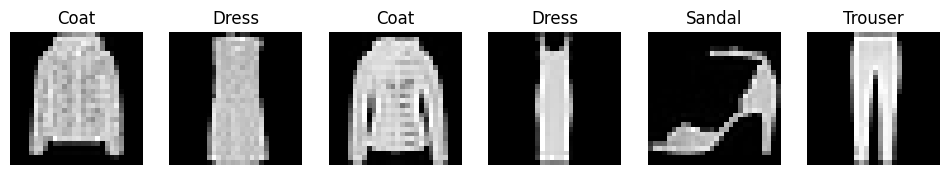

--- Running Example Experiment ---
Train Loss: 0.4528 | Test Loss: 0.5727 | Train Acc: 84.57% | Test Acc: 81.01%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloaders(dataset_name, batch_size):
    if dataset_name in ['MNIST', 'FashionMNIST']:
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        input_size = 784 # 28x28
    else: # CIFAR-10
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        input_size = 3072 # 3x32x32

    if dataset_name == 'FashionMNIST':
        trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
        classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    elif dataset_name == 'MNIST':
        trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        classes = [str(i) for i in range(10)]
    else:
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, input_size, classes

def visualize_samples(train_loader, classes):
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    print(f"Image batch shape: {images.shape}")
    print(f"Labels batch shape: {labels.shape}")

    fig, axes = plt.subplots(1, 6, figsize=(12, 2))
    for i in range(6):
        img = images[i] / 2 + 0.5     # unnormalize
        npimg = img.numpy()
        axes[i].imshow(np.transpose(npimg, (1, 2, 0)) if img.shape[0] == 3 else npimg.squeeze(), cmap='gray')
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')
    plt.show()

class Model1(nn.Module):
    # Task 2: Input -> 16 -> 10
    def __init__(self, input_size, use_dropout=False):
        super(Model1, self).__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(input_size, 16)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(16, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        if self.use_dropout: x = self.dropout(x)
        x = self.fc2(x)
        return x

class Model2(nn.Module):
    # Task 3: Input -> 128 -> 64 -> 10
    def __init__(self, input_size, use_dropout=False):
        super(Model2, self).__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        if self.use_dropout: x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        if self.use_dropout: x = self.dropout(x)
        x = self.fc3(x)
        return x

class Model3(nn.Module):
    # Task 4: Input -> 512 -> 256 -> 128 -> 64 -> 10
    def __init__(self, input_size, use_dropout=False):
        super(Model3, self).__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc5 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        if self.use_dropout: x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        if self.use_dropout: x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        if self.use_dropout: x = self.dropout(x)
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return x

def train_and_evaluate(model, train_loader, test_loader, epochs, lr, use_early_stopping=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    best_loss = float('inf')
    patience = 3 # Early stopping patience
    epochs_no_improve = 0

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Evaluation Phase
        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        # Task 7: Early Stopping Logic
        if use_early_stopping:
            if test_loss < best_loss:
                best_loss = test_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve == patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break

    return train_losses[-1], test_losses[-1], train_accs[-1], test_accs[-1]

DATASET = 'FashionMNIST'
BATCH_SIZE = 64
train_loader, test_loader, input_size, classes = get_dataloaders(DATASET, BATCH_SIZE)

print("--- Task 1: Visualizing Dataset ---")
visualize_samples(train_loader, classes)

print("--- Running Example Experiment ---")
train_loader_32, test_loader_32, _, _ = get_dataloaders(DATASET, 32)
model1 = Model1(input_size=input_size, use_dropout=False).to(device)
tr_loss, ts_loss, tr_acc, ts_acc = train_and_evaluate(model1, train_loader_32, test_loader_32, epochs=10, lr=0.01)

print(f"Train Loss: {tr_loss:.4f} | Test Loss: {ts_loss:.4f} | Train Acc: {tr_acc:.2f}% | Test Acc: {ts_acc:.2f}%")